In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import opensim as osim
import pickle
from scipy.signal import find_peaks
from OA_utils.data_utils import (
    ad2float, interp_segments, exclude_segments,
    get_all_segments, flatten_to_muscle_dict,
    normalize_by_mass_in_order, filter_segments,
    plot_muscle_grid
)

# Config

In [2]:
data_dir = '/Users/briankeller/Desktop/GRFMuscleModel/data'

trial_names = [
    'walking_baseline1',
    'walking_FBexp1_finalNoFB1', 'walking_FBexp1_finalFB1',
    'walking_FBcolor1_finalNoFB1', 'walking_FBcolor1_finalFB1',
    'walking_FBcolor2_finalNoFB1', 'walking_FBcolor2_finalFB1',
    'walking_retention1'
]

subject_ids = list(range(1, 11))  # Subject1 .. Subject10

subj_masses = [86.04, 50.71, 92.25, 65.31, 69.29, 83.48, 61.98, 68.73, 66.3, 64.22]

# Full muscle set matching OA_BatchProcessing
muscles = [
    'addbrev_r', 'addlong_r', 'addmagDist_r', 'addmagIsch_r', 'addmagMid_r', 'addmagProx_r',
    'bflh_r', 'bfsh_r', 'edl_r', 'ehl_r', 'fdl_r', 'fhl_r', 'gaslat_r', 'gasmed_r',
    'glmax1_r', 'glmax2_r', 'glmax3_r', 'glmed1_r', 'glmed2_r', 'glmed3_r',
    'glmin1_r', 'glmin2_r', 'glmin3_r', 'grac_r', 'iliacus_r', 'perbrev_r', 'perlong_r',
    'psoas_r', 'recfem_r', 'semimem_r', 'semiten_r', 'soleus_r',
    'tibant_r', 'tibpost_r', 'vasint_r', 'vaslat_r', 'vasmed_r',

    'addbrev_l', 'addlong_l', 'addmagDist_l', 'addmagIsch_l', 'addmagMid_l', 'addmagProx_l',
    'bflh_l', 'bfsh_l', 'edl_l', 'ehl_l', 'fdl_l', 'fhl_l', 'gaslat_l', 'gasmed_l',
    'glmax1_l', 'glmax2_l', 'glmax3_l', 'glmed1_l', 'glmed2_l', 'glmed3_l',
    'glmin1_l', 'glmin2_l', 'glmin3_l', 'grac_l', 'iliacus_l', 'perbrev_l', 'perlong_l',
    'psoas_l', 'recfem_l', 'semimem_l', 'semiten_l', 'soleus_l',
    'tibant_l', 'tibpost_l', 'vasint_l', 'vaslat_l', 'vasmed_l'
]
base_muscles = sorted({m[:-2] for m in muscles if m.endswith(('_r', '_l'))})
base_muscles.append('achilles')
print(f'{len(base_muscles)} muscles (including achilles): {base_muscles}')

38 muscles (including achilles): ['addbrev', 'addlong', 'addmagDist', 'addmagIsch', 'addmagMid', 'addmagProx', 'bflh', 'bfsh', 'edl', 'ehl', 'fdl', 'fhl', 'gaslat', 'gasmed', 'glmax1', 'glmax2', 'glmax3', 'glmed1', 'glmed2', 'glmed3', 'glmin1', 'glmin2', 'glmin3', 'grac', 'iliacus', 'perbrev', 'perlong', 'psoas', 'recfem', 'semimem', 'semiten', 'soleus', 'tibant', 'tibpost', 'vasint', 'vaslat', 'vasmed', 'achilles']


# Extract Gait Segments

Load GRF `.mot` and Static Optimization `results_forces.sto` for each subject and trial.
Segments are detected from zero-crossings in the vertical GRF, then filtered by threshold checks
to remove missteps. Both right and left limbs are included; the medial-lateral GRF is sign-flipped
for left contacts.

In [3]:
def load_muscle_side(storage, base_muscle_names, side):
    """Return {base_name: np.array} for one side ('r' or 'l')."""
    out = {}
    for m in base_muscle_names:
        col = osim.ArrayDouble()
        storage.getDataColumn(f'{m}_{side}', col)
        out[m] = ad2float(col)
    return out


compiled_segs = {}
base_no_achilles = [m for m in base_muscles if m != 'achilles']

for sid in subject_ids:
    subj_key = f'Subject{sid}'
    compiled_segs[subj_key] = {
        'grf_x': [], 'grf_y': [], 'grf_z': [],
        'cop_x': [], 'cop_y': [], 'cop_z': [],
        **{m: [] for m in base_muscles}
    }
    subj_data = compiled_segs[subj_key]

    for trial in trial_names:
        grf_path    = f'{data_dir}/{subj_key}/ExpmtlData/GRF/{trial}_forces.mot'
        muscle_path = f'{data_dir}/{subj_key}/StaticOpt/{trial}/results_forces.sto'

        if not os.path.exists(grf_path) or not os.path.exists(muscle_path):
            print(f'  Missing: {subj_key}/{trial} — skipping')
            continue

        grf_storage    = osim.Storage(grf_path)
        muscle_storage = osim.Storage(muscle_path)

        # --- time ---
        time_col = osim.ArrayDouble()
        grf_storage.getTimeColumn(time_col)
        time_arr = ad2float(time_col)

        # --- GRF right ---
        def _load_grf(storage, col_name):
            c = osim.ArrayDouble()
            storage.getDataColumn(col_name, c)
            return ad2float(c)

        grf_x_r = _load_grf(grf_storage, 'ground_force_vx')
        grf_y_r = _load_grf(grf_storage, 'ground_force_vy')
        grf_z_r = _load_grf(grf_storage, 'ground_force_vz')
        cop_x_r = _load_grf(grf_storage, 'ground_force_px')
        cop_y_r = _load_grf(grf_storage, 'ground_force_py')
        cop_z_r = _load_grf(grf_storage, 'ground_force_pz')

        # --- GRF left ---
        grf_x_l = _load_grf(grf_storage, '1_ground_force_vx')
        grf_y_l = _load_grf(grf_storage, '1_ground_force_vy')
        grf_z_l = _load_grf(grf_storage, '1_ground_force_vz')
        cop_x_l = _load_grf(grf_storage, '1_ground_force_px')
        cop_y_l = _load_grf(grf_storage, '1_ground_force_py')
        cop_z_l = _load_grf(grf_storage, '1_ground_force_pz')

        # --- muscles ---
        mdata_r = load_muscle_side(muscle_storage, base_no_achilles, 'r')
        mdata_l = load_muscle_side(muscle_storage, base_no_achilles, 'l')

        # --- detect stance phases from GRF zero-crossings ---
        for side in ('r', 'l'):
            grf_y = grf_y_r if side == 'r' else grf_y_l
            grf_x = grf_x_r if side == 'r' else grf_x_l
            grf_z = grf_z_r if side == 'r' else grf_z_l
            cop_x = cop_x_r if side == 'r' else cop_x_l
            cop_y = cop_y_r if side == 'r' else cop_y_l
            cop_z = cop_z_r if side == 'r' else cop_z_l
            mdata  = mdata_r  if side == 'r' else mdata_l
            z_sign = 1.0      if side == 'r' else -1.0

            crossings = np.where(np.diff(grf_y > 0) == 1)[0] + 1
            if grf_y[0] > 0:
                crossings = crossings[1:]
            n_segs = len(crossings) // 2

            for j in range(n_segs):
                s_idx = crossings[2 * j] - 1
                e_idx = crossings[2 * j + 1] + 1

                grf_y_seg = grf_y[s_idx:e_idx]
                grf_x_seg = grf_x[s_idx:e_idx]
                grf_z_seg = z_sign * grf_z[s_idx:e_idx]

                # misstep filter
                idx10 = int(len(grf_y_seg) * 0.10)
                idx30 = int(len(grf_y_seg) * 0.30)
                idx80 = int(len(grf_y_seg) * 0.80)
                if grf_y_seg[idx10] < 100 or grf_y_seg[idx80] < 300 or grf_y_seg[idx30] < 475:
                    continue

                # COP with forward-progression correction
                cop_x_seg = np.zeros_like(grf_y_seg)
                cop_y_seg = np.zeros_like(grf_y_seg)
                cop_z_seg = np.zeros_like(grf_y_seg)
                peak_idxs, _ = find_peaks(grf_y_seg,
                                          height=0.5 * np.max(grf_y_seg),
                                          distance=int(0.2 * 50))
                if peak_idxs.size >= 2:
                    pk1, pk2 = peak_idxs[0], peak_idxs[1]
                    t_seg = time_arr[pk1:pk2] - time_arr[pk1]
                    cop_corr = t_seg * 1.25
                    cx = cop_x[s_idx:e_idx]
                    cop_x_seg[pk1:pk2] = cx[pk1:pk2] - cx[pk1] + cop_corr
                    cy = cop_y[s_idx:e_idx]
                    cop_y_seg[pk1:pk2] = cy[pk1:pk2] - cy[pk1]
                    cz = cop_z[s_idx:e_idx]
                    cop_z_seg[pk1:pk2] = cz[pk1:pk2] - cz[pk1]

                # ehl sanity check (kept from original)
                ehl_seg = mdata['ehl'][s_idx:e_idx]
                if ehl_seg.max() > 100:
                    continue

                subj_data['grf_x'].append(grf_x_seg)
                subj_data['grf_y'].append(grf_y_seg)
                subj_data['grf_z'].append(grf_z_seg)
                subj_data['cop_x'].append(cop_x_seg)
                subj_data['cop_y'].append(cop_y_seg)
                subj_data['cop_z'].append(cop_z_seg)

                for m in base_no_achilles:
                    subj_data[m].append(mdata[m][s_idx:e_idx])

                subj_data['achilles'].append(
                    mdata['gaslat'][s_idx:e_idx] +
                    mdata['gasmed'][s_idx:e_idx] +
                    mdata['soleus'][s_idx:e_idx]
                )

    n = len(subj_data['grf_y'])
    print(f'{subj_key}: {n} segments')

total = sum(len(v['grf_y']) for v in compiled_segs.values())
print(f'\nTotal: {total} segments')

[info] Storage: read data file = /Users/briankeller/Desktop/GRFMuscleModel/data/Subject1/ExpmtlData/GRF/walking_baseline1_forces.mot (nr=121120 nc=19)
[info] Storage: read data file = /Users/briankeller/Desktop/GRFMuscleModel/data/Subject1/StaticOpt/walking_baseline1/results_forces.sto (nr=3028 nc=118)
[info] Storage: read data file = /Users/briankeller/Desktop/GRFMuscleModel/data/Subject1/ExpmtlData/GRF/walking_FBexp1_finalNoFB1_forces.mot (nr=122200 nc=19)
[info] Storage: read data file = /Users/briankeller/Desktop/GRFMuscleModel/data/Subject1/StaticOpt/walking_FBexp1_finalNoFB1/results_forces.sto (nr=3055 nc=118)
[info] Storage: read data file = /Users/briankeller/Desktop/GRFMuscleModel/data/Subject1/ExpmtlData/GRF/walking_FBexp1_finalFB1_forces.mot (nr=121160 nc=19)
[info] Storage: read data file = /Users/briankeller/Desktop/GRFMuscleModel/data/Subject1/StaticOpt/walking_FBexp1_finalFB1/results_forces.sto (nr=3029 nc=118)
[info] Storage: read data file = /Users/briankeller/Desktop/

# Length-Based Exclusion

Drop segments whose raw sample count falls outside [20, 70] — same bounds as the original Ulrich pipeline.

In [4]:
all_keys = ['grf_x', 'grf_y', 'grf_z', 'cop_x', 'cop_y', 'cop_z'] + base_muscles

for subj, data in compiled_segs.items():
    for key in all_keys:
        data[key] = exclude_segments(data[key], 20, 70)

total = sum(len(v['grf_y']) for v in compiled_segs.values())
print(f'{total} segments after length filter')

14892 segments after length filter


# Resample to 100 Points

In [5]:
n_interp_points = 100
resampled_segs = {}

for subj, subj_data in compiled_segs.items():
    resampled_segs[subj] = {}
    for key, seg_list in subj_data.items():
        if len(seg_list) == 0:
            resampled_segs[subj][key] = []
            continue
        resampled, time_resampled = interp_segments(seg_list, n_interp_points)
        resampled_segs[subj][key] = resampled

resampled_segs['time_resampled'] = time_resampled

total = sum(len(v.get('grf_y', [])) for v in resampled_segs.values() if isinstance(v, dict))
print(f'{total} segments after resampling')

14892 segments after resampling


# Normalize by Body Mass (N → N/kg)

In [6]:
normalizer_keys = [m for m in base_muscles] + ['grf_x', 'grf_y', 'grf_z']

normalized_segs = normalize_by_mass_in_order(resampled_segs, subj_masses, normalizer_keys)

# MAD / % Outside Filter

Drop segments where:
- RMS of excess beyond the ±2.5 std band exceeds `rms_threshold`, **or**
- More than `mean_threshold` fraction of timepoints fall outside ±2 std of the population mean

In [7]:
consistency_mode = 'any'
rms_threshold    = 0.75
mean_threshold   = 0.5

normalized_segs_filtered, dropped, bands = filter_segments(
    seg_dict=normalized_segs,
    muscle_keys=base_muscles,
    consistency_mode=consistency_mode,
    rms_threshold=rms_threshold,
    mean_threshold=mean_threshold,
)

n_before = sum(len(d.get('achilles', [])) for d in normalized_segs.values() if isinstance(d, dict))
n_after  = sum(len(d.get('achilles', [])) for d in normalized_segs_filtered.values() if isinstance(d, dict))
print(f'Segments before: {n_before}')
print(f'Segments after : {n_after}')
print(f'Dropped        : {len(dropped)} ({100*len(dropped)/n_before:.1f}%)')

from collections import Counter
c = Counter()
for _, _, bad in dropped:
    c.update(bad)
print('\nTop muscles triggering drops:')
for muscle, count in c.most_common(10):
    print(f'  {muscle:<20} {count}')

Segments before: 14892
Segments after : 10584
Dropped        : 4308 (28.9%)

Top muscles triggering drops:
  addmagDist           1343
  semimem              1285
  addmagProx           972
  psoas                961
  addmagMid            859
  glmed1               844
  ehl                  818
  iliacus              748
  vaslat               713
  tibpost              542


# Plot GRF

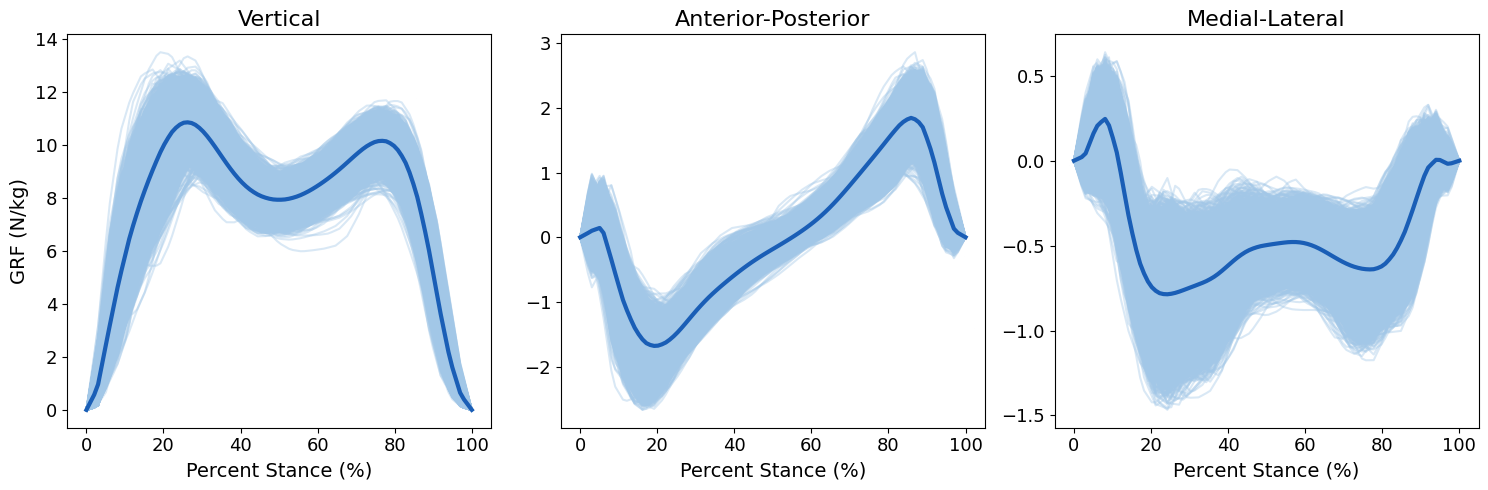

In [8]:
grf_y_resampled = get_all_segments(normalized_segs_filtered, 'grf_y')
grf_x_resampled = get_all_segments(normalized_segs_filtered, 'grf_x')
grf_z_resampled = get_all_segments(normalized_segs_filtered, 'grf_z')
time_resampled  = normalized_segs_filtered['time_resampled']
t = time_resampled[0] * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True)
components = [('Vertical', grf_y_resampled), ('Anterior-Posterior', grf_x_resampled), ('Medial-Lateral', grf_z_resampled)]
for ax, (label, arr) in zip(axes, components):
    for seg in arr:
        ax.plot(t, seg, color='#A2C7E7', linewidth=1.5, alpha=0.4)
    ax.plot(t, np.mean(arr, axis=0), color='#1A5EB6', linewidth=3)
    ax.set_title(label, fontsize=16)
    ax.set_xlabel('Percent Stance (%)', fontsize=14)
    ax.tick_params(labelsize=13)
axes[0].set_ylabel('GRF (N/kg)', fontsize=14)
plt.tight_layout()
plt.show()

# Plot Filtered Muscle Forces

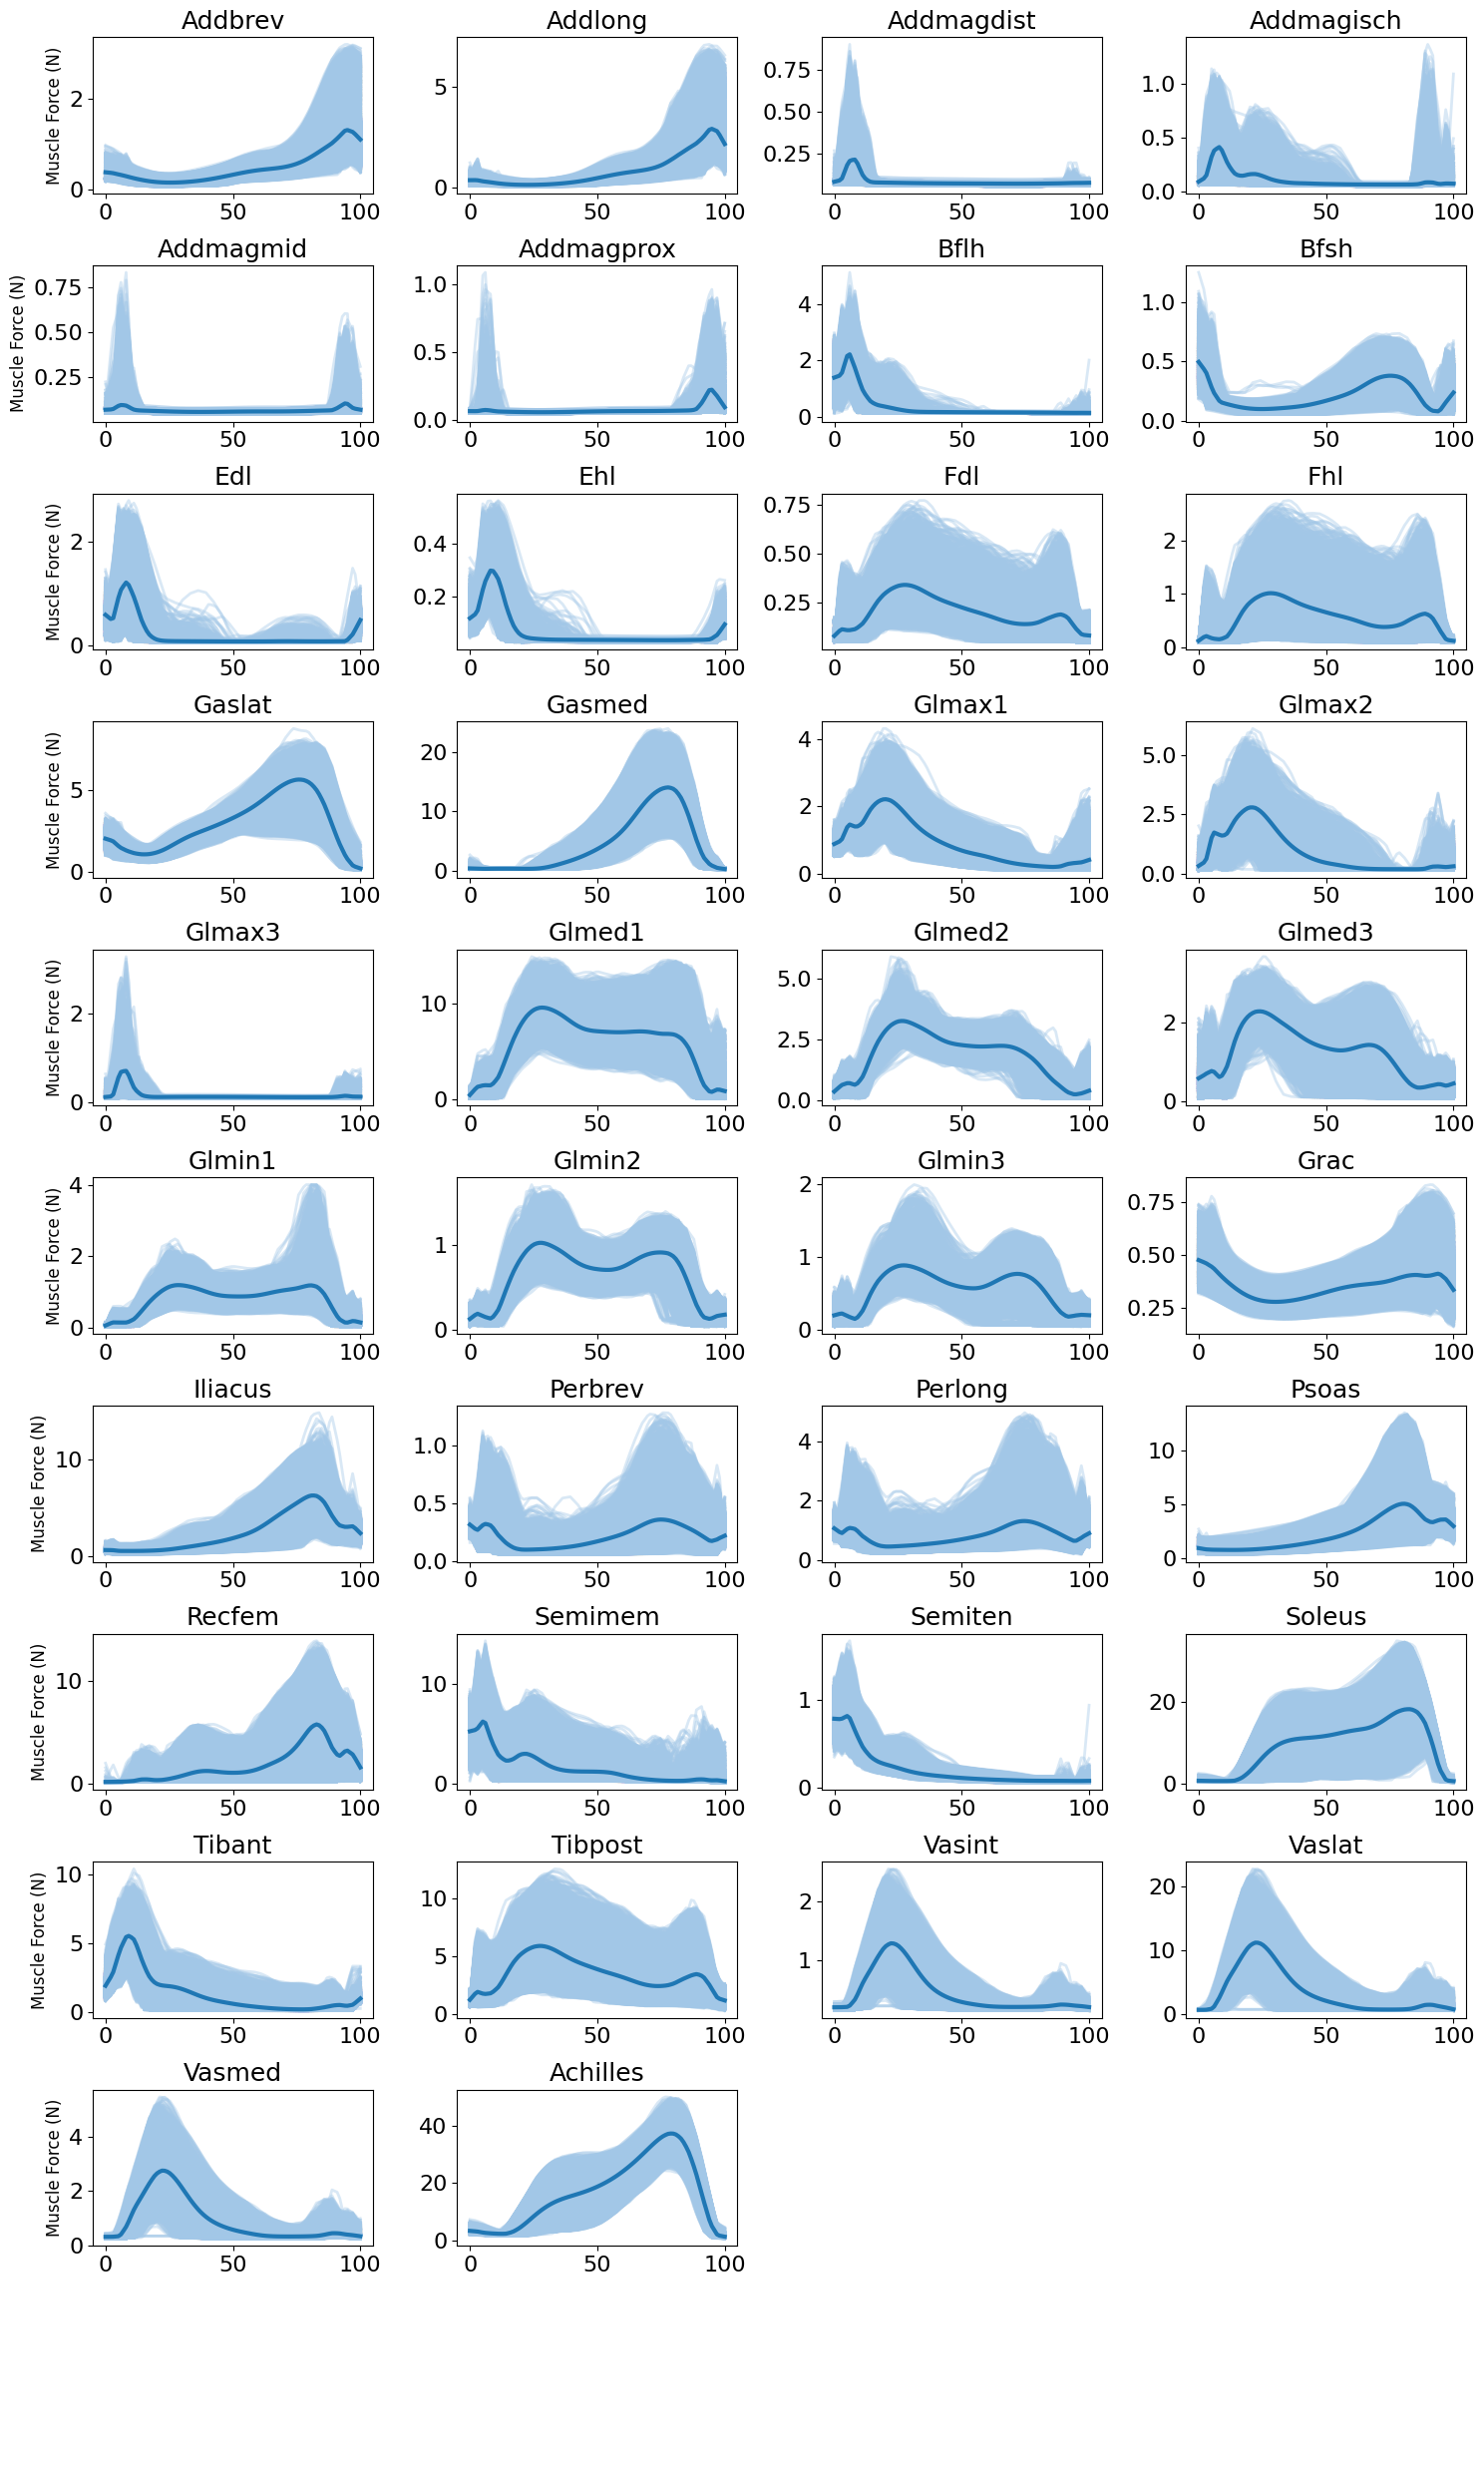

In [9]:
resampled_filtered_muscles = flatten_to_muscle_dict(normalized_segs_filtered, base_muscles)

plot_muscle_grid(
    resampled_filtered_muscles,
    time_resampled,
    base_muscles,
    plot_mean=True
)

In [10]:
subj_keys = [k for k in normalized_segs_filtered if isinstance(k, str) and k != 'time_resampled']
signal_keys = [k for k in next(v for v in normalized_segs_filtered.values() if isinstance(v, dict))]

print(f"{'='*65}")
print(f"  Ulrich filtered segments  ({len(subj_keys)} subjects)")
print(f"{'='*65}")

total = 0
for subj in sorted(subj_keys, key=lambda s: int(s.replace('Subject', ''))):
    data = normalized_segs_filtered[subj]
    n = len(data.get('grf_y', []))
    total += n
    print(f"\n  {subj}  —  {n} segments")
    print(f"    signals ({len(signal_keys)}): {', '.join(sorted(signal_keys))}")

print(f"\n{'='*65}")
print(f"  Total segments : {total}")
print(f"  Total signals  : {len(signal_keys)}")
print(f"  Signal length  : {normalized_segs_filtered['time_resampled'][0].shape[0]} points")


  Ulrich filtered segments  (10 subjects)

  Subject1  —  1181 segments
    signals (44): achilles, addbrev, addlong, addmagDist, addmagIsch, addmagMid, addmagProx, bflh, bfsh, cop_x, cop_y, cop_z, edl, ehl, fdl, fhl, gaslat, gasmed, glmax1, glmax2, glmax3, glmed1, glmed2, glmed3, glmin1, glmin2, glmin3, grac, grf_x, grf_y, grf_z, iliacus, perbrev, perlong, psoas, recfem, semimem, semiten, soleus, tibant, tibpost, vasint, vaslat, vasmed

  Subject2  —  2 segments
    signals (44): achilles, addbrev, addlong, addmagDist, addmagIsch, addmagMid, addmagProx, bflh, bfsh, cop_x, cop_y, cop_z, edl, ehl, fdl, fhl, gaslat, gasmed, glmax1, glmax2, glmax3, glmed1, glmed2, glmed3, glmin1, glmin2, glmin3, grac, grf_x, grf_y, grf_z, iliacus, perbrev, perlong, psoas, recfem, semimem, semiten, soleus, tibant, tibpost, vasint, vaslat, vasmed

  Subject3  —  1418 segments
    signals (44): achilles, addbrev, addlong, addmagDist, addmagIsch, addmagMid, addmagProx, bflh, bfsh, cop_x, cop_y, cop_z, edl, eh

# Export

In [11]:
out_path = '/Users/briankeller/Desktop/GRFMuscleModel/data/Ulrich_segs_normalized_filtered'
with open(out_path, 'wb') as f:
    pickle.dump(normalized_segs_filtered, f)
print(f'Saved {n_after} segments → {out_path}')

Saved 10584 segments → /Users/briankeller/Desktop/GRFMuscleModel/data/Ulrich_segs_normalized_filtered
